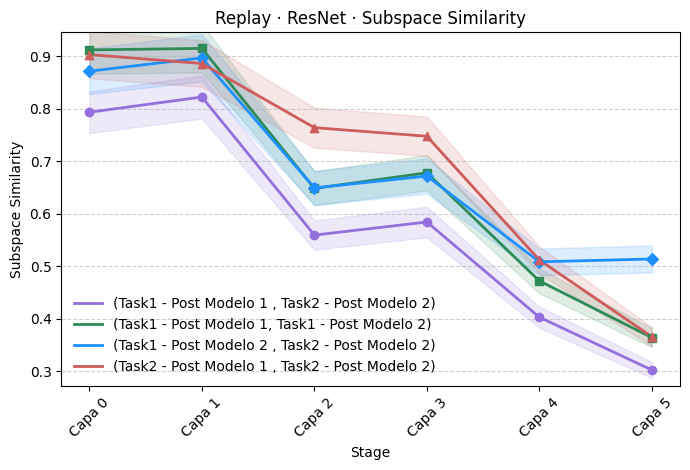

In [4]:
#!/usr/bin/env python3
# subspace_plot.py – Figura global + figuras individuales de Subspace Similarity

import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# ────────────────────────── 1. Interpolación opcional ─────────────────────────────
try:
    from scipy.interpolate import CubicSpline
    _CS = False
except ImportError:
    print("ℹ️  SciPy no está instalado: se usará interpolación lineal.")
    _CS = False

# ────────────────────────── 2. Archivos JSON ──────────────────────────────────
files = {
    "(Task1 - Post Modelo 1 , Task2 - Post Modelo 2)":    "sim_t1ck1_vs_t2ck2d.json",
    "(Task1 - Post Modelo 1, Task1 - Post Modelo 2)":     "sim_t1ck1_vs_t1ck2d.json",
    "(Task1 - Post Modelo 2 , Task2 - Post Modelo 2)":    "sim_t1ck2_vs_t2ck2d.json",
    "(Task2 - Post Modelo 1 , Task2 - Post Modelo 2)":    "sim_t2ck1_vs_t2ck2d.json"
}

stage_order = ["backbone.conv1", "backbone.bn1", "backbone.layer1.1",
               "backbone.layer2.1", "backbone.layer3.1", "backbone.layer4.1"]

common, raw = None, {}
for lab, path in files.items():
    with open(path) as f:
        layers = json.load(f)["layers"]
    raw[lab] = layers
    common = set(layers) if common is None else common & layers.keys()

layers_full = [l for l in stage_order if l in common]
curves = {lab: np.array([raw[lab][k] for k in layers_full]) for lab in raw}

orig_x  = np.arange(len(layers_full))
dense_x = np.linspace(orig_x[0], orig_x[-1], len(layers_full) * 3 - 2)
etiquetas_personalizadas = ["Capa 0", "Capa 1", "Capa 2", "Capa 3", "Capa 4", "Capa 5"]

# ────────────────────────── 3. Estilo ─────────────────────────────────────────
markers = ["o", "s", "D", "^"]
colors  = ["mediumpurple", "seagreen", "dodgerblue", "indianred"]

# ────────────── FIGURA GENERAL ──────────────
plt.figure(figsize=(7, 4.8))
for i, (lab, y) in enumerate(curves.items()):
    col, mark = colors[i % len(colors)], markers[i % len(markers)]
    y_dense = CubicSpline(orig_x, y)(dense_x) if _CS and len(y) >= 3 else np.interp(dense_x, orig_x, y)

    plt.plot(dense_x, y_dense, lw=2, label=lab, color=col)
    plt.scatter(orig_x, y, marker=mark, color=col, zorder=3)
    plt.fill_between(dense_x, y_dense*0.95, y_dense*1.05, color=col, alpha=0.15)

# Rango Y automático
y_vals = np.concatenate(list(curves.values()))
ymin, ymax = y_vals.min(), y_vals.max()
margin = 0.05 * (ymax - ymin if ymax != ymin else 1)
plt.ylim(max(0, ymin - margin), min(1, ymax + margin))

plt.xticks(orig_x, etiquetas_personalizadas, rotation=45)
plt.xlabel("Stage"); plt.ylabel("Subspace Similarity")
plt.title("Replay · ResNet · Subspace Similarity")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("subspace_all.png", dpi=300, bbox_inches="tight")
plt.show()

# ────────────── FIGURAS INDIVIDUALES ──────────────
for i, (lab, y) in enumerate(curves.items()):
    plt.figure(figsize=(6, 4.2))
    col, mark = colors[i % len(colors)], markers[i % len(markers)]
    y_dense = CubicSpline(orig_x, y)(dense_x) if _CS and len(y) >= 3 else np.interp(dense_x, orig_x, y)

    plt.plot(dense_x, y_dense, lw=2, label=lab, color=col)
    plt.scatter(orig_x, y, marker=mark, color=col, zorder=3)
    plt.fill_between(dense_x, y_dense*0.95, y_dense*1.05, color=col, alpha=0.15)

    plt.xticks(orig_x, etiquetas_personalizadas, rotation=45)
    plt.ylim(max(0, ymin - margin), min(1, ymax + margin))
    plt.xlabel("Stage"); plt.ylabel("Subspace Similarity")
    plt.title(f"Replay · {lab}")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Guardar con prefijo "finetune_"
    clean_name = lab.replace("(", "").replace(")", "").replace(",", "").replace(" ", "_")
    filename = f"replay_{clean_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

# print("✅ Figuras guardadas: subspace_all.png + una imagen por cada curva (prefijo 'finetune_')")
